In [343]:
import pandas as pd

df= pd.read_csv("https://raw.githubusercontent.com/williamsabrahamflorianolara-boop/estadistica2026b/refs/heads/main/ExamenPractico/diabetes_prediction_dataset.csv")

df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [345]:
df.dropna(inplace=True)
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [346]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [347]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [348]:
#Tirar
df.drop(columns=["smoking_history"],inplace = True)

In [349]:
df=df[df["gender"]!="Other"]

In [350]:
print(df['gender'].unique())

['Female' 'Male']


In [351]:
df = df.dropna(subset=['gender'])
df

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,25.19,6.6,140,0
1,Female,54.0,0,0,27.32,6.6,80,0
2,Male,28.0,0,0,27.32,5.7,158,0
3,Female,36.0,0,0,23.45,5.0,155,0
4,Male,76.0,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,27.32,6.2,90,0
99996,Female,2.0,0,0,17.37,6.5,100,0
99997,Male,66.0,0,0,27.83,5.7,155,0
99998,Female,24.0,0,0,35.42,4.0,100,0


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
Female   Male   1.4211   0.0 0.9089 1.9333   True
-------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

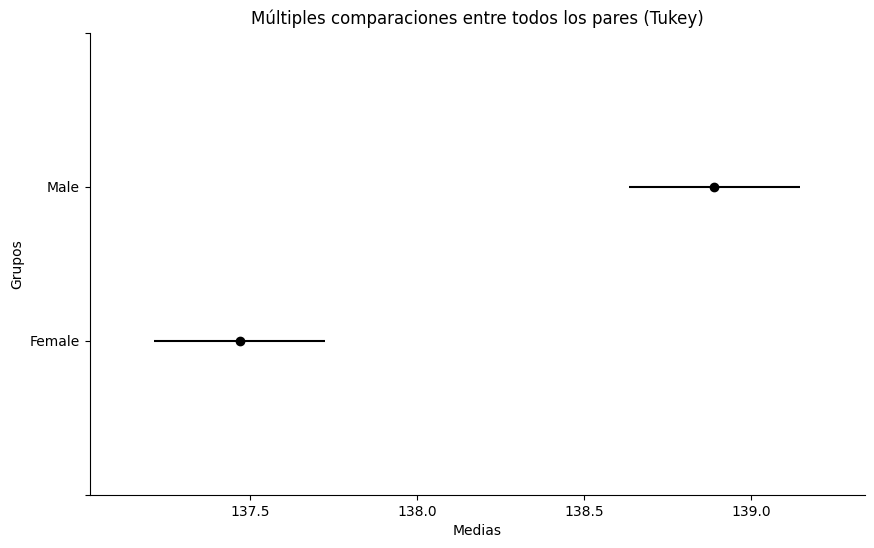

In [352]:
#test de tukey
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['blood_glucose_level'], groups=df['gender'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [353]:
df["gender"]=df["gender"].map({"Female":0,"Male":1})
df

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,25.19,6.6,140,0
1,0,54.0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,23.45,5.0,155,0
4,1,76.0,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...
99995,0,80.0,0,0,27.32,6.2,90,0
99996,0,2.0,0,0,17.37,6.5,100,0
99997,1,66.0,0,0,27.83,5.7,155,0
99998,0,24.0,0,0,35.42,4.0,100,0


In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99982 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               99982 non-null  int64  
 1   age                  99982 non-null  float64
 2   hypertension         99982 non-null  int64  
 3   heart_disease        99982 non-null  int64  
 4   bmi                  99982 non-null  float64
 5   HbA1c_level          99982 non-null  float64
 6   blood_glucose_level  99982 non-null  int64  
 7   diabetes             99982 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 6.9 MB


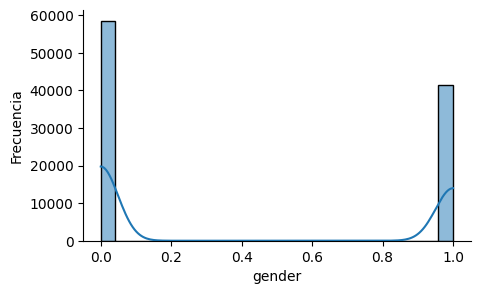

In [355]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['gender'], kde=True)
plt.xlabel("gender")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

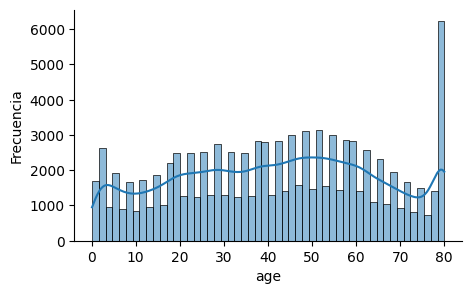

In [356]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['age'], kde=True)
plt.xlabel("age")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

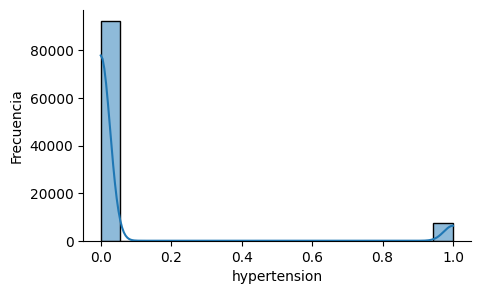

In [357]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['hypertension'], kde=True)
plt.xlabel("hypertension")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

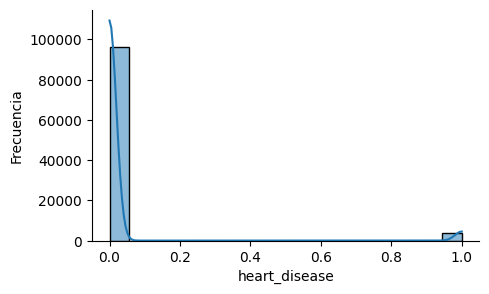

In [358]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['heart_disease'], kde=True)
plt.xlabel("heart_disease")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

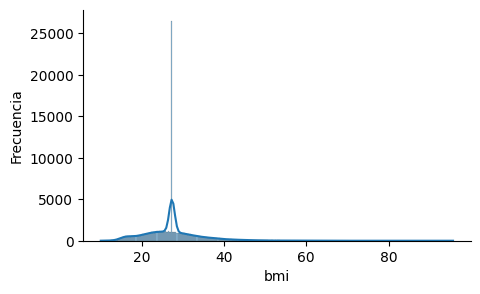

In [359]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['bmi'], kde=True)
plt.xlabel("bmi")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

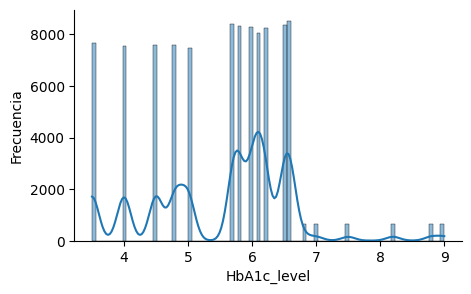

In [360]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['HbA1c_level'], kde=True)
plt.xlabel("HbA1c_level")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

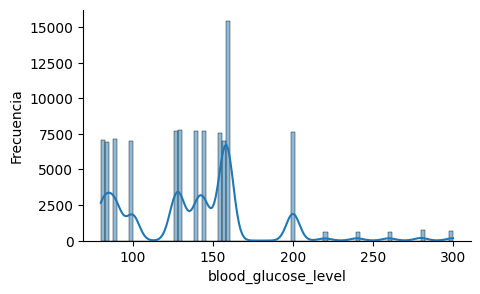

In [361]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['blood_glucose_level'], kde=True)
plt.xlabel("blood_glucose_level")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

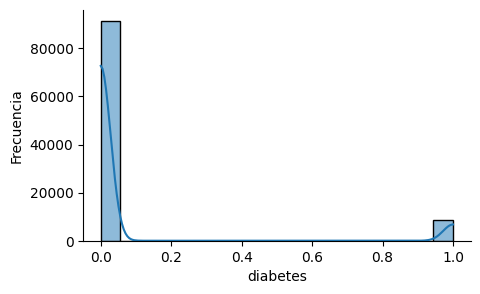

In [362]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['diabetes'], kde=True)
plt.xlabel("diabetes")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

In [363]:
import seaborn as sns          # Librería para visualización estadística
import matplotlib.pyplot as plt  # Librería base para gráficos

# Calcula la matriz de correlación entre variables numéricas del DataFrame
correlation_matrix = df.corr()

plt.figure(
    figsize=(40, 30), # Define el tamaño de la figura (ancho, alto)
    dpi = 300  # Calidad de la imagen dpi=50 (estandar) dpi = 300 (alta calidad)
    )

# Construye el mapa de calor de la matriz de correlación
sns.heatmap(
    correlation_matrix,   # Datos: matriz de correlación
    annot=True,           # Muestra los valores numéricos en cada celda
    cmap='coolwarm',      # Paleta de colores (azul = negativo, rojo = positivo)
    fmt=".4f",            # Formato de los números (4 decimales)
    square=True,          # Hace que cada celda sea cuadrada
    center=0,             # Centra la escala de colores en 0 (muy importante)
    cbar_kws={"shrink": .8}  # Reduce el tamaño de la barra de color
)

# Título del gráfico
plt.title('Mapa de Calor de la Matriz de Correlación')

# Muestra la gráfica en pantalla
plt.show()

In [364]:
#Analisis de multicolinealidad
df=df[["gender","age","hypertension","heart_disease","bmi","HbA1c_level","blood_glucose_level","diabetes"]]
df

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,25.19,6.6,140,0
1,0,54.0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,23.45,5.0,155,0
4,1,76.0,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...
99995,0,80.0,0,0,27.32,6.2,90,0
99996,0,2.0,0,0,17.37,6.5,100,0
99997,1,66.0,0,0,27.83,5.7,155,0
99998,0,24.0,0,0,35.42,4.0,100,0


In [365]:
import seaborn as sns          # Librería para visualización estadística
import matplotlib.pyplot as plt  # Librería base para gráficos

# Calcula la matriz de correlación entre variables numéricas del DataFrame
correlation_matrix = df.corr()

plt.figure(
    figsize=(40, 30), # Define el tamaño de la figura (ancho, alto)
    dpi = 300  # Calidad de la imagen dpi=50 (estandar) dpi = 300 (alta calidad)
    )

# Construye el mapa de calor de la matriz de correlación
sns.heatmap(
    correlation_matrix,   # Datos: matriz de correlación
    annot=True,           # Muestra los valores numéricos en cada celda
    cmap='coolwarm',      # Paleta de colores (azul = negativo, rojo = positivo)
    fmt=".4f",            # Formato de los números (4 decimales)
    square=True,          # Hace que cada celda sea cuadrada
    center=0,             # Centra la escala de colores en 0 (muy importante)
    cbar_kws={"shrink": .8}  # Reduce el tamaño de la barra de color
)

# Título del gráfico
plt.title('Mapa de Calor de la Matriz de Correlación')

# Muestra la gráfica en pantalla
plt.show()

In [366]:
x=df [["diabetes","age"]]
y=df ["blood_glucose_level"]

In [367]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,132.662717
diabetes,61.145684
age,0.004698


El modelo es:

**ŷ= 132.662717 + 	61.145684x**

Donde x es diabetes

**ŷ= 132.662717 + 0.004698x**

Donde x es age

In [368]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  17.61%


In [369]:
residuales = modelo.resid

valor-p (Shapiro) = 2.0526207414946845e-101


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 99982.
  res = hypotest_fun_out(*samples, **kwds)


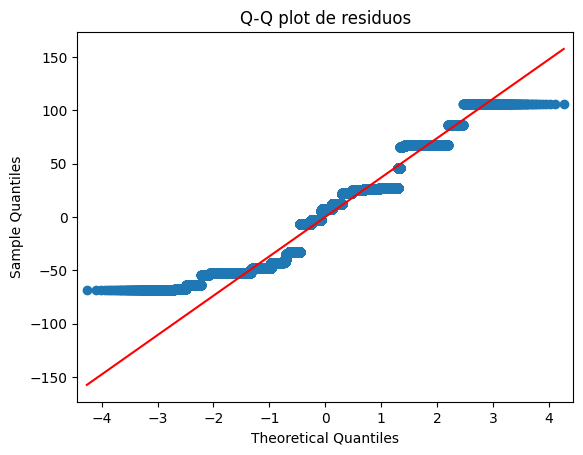

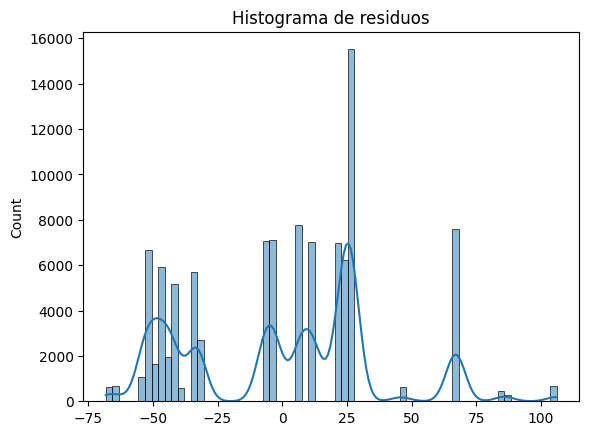

In [370]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [371]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000



In [372]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''blood_glucose_level ~ diabetes+age''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
diabetes,1.0,2.917113e+07,2.917113e+07,21362.792196,0.000000
age,1.0,1.044214e+03,1.044214e+03,0.764705,0.381862
Residual,99979.0,1.365224e+08,1.365511e+03,NaN,NaN
